In [11]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [12]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [13]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state


In [14]:
def fit_label(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state    

In [15]:
#DEFINE Graph

graph = StateGraph(BMIState)

#add nodes to the graph 
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("fit_label",fit_label)

#add edges to the graph
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi","fit_label")
graph.add_edge("calculate_bmi",END)
# compile the graph
workflow = graph.compile()
#execute the graph
initial_state = {'weight':80, 'height':1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 80, 'height': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


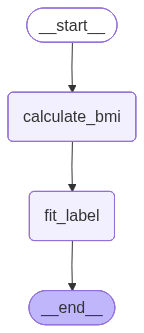

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())